In [3]:
# !pip install wfdb  # uncomment if not already installed

import wfdb
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Class mapping (AAMI EC57)

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}

def map_beats(ann):
    """Return (sample, aami_label) pairs, dropping non-beat annotations."""
    filtered = []
    for sample, symbol in zip(ann.sample, ann.symbol):
        label = aami_map.get(symbol)
        if label is not None:
            filtered.append((sample, label))
    return filtered

In [5]:
## Train/test split (DS1/DS2)

DS1 = [101,106,108,109,112,114,115,116,118,119,122,124,201,203,205,207,208,209,215,220,223,230]
DS2 = [100,103,105,111,113,117,121,123,200,202,210,212,213,214,219,221,222,228,231,232,233,234]

In [6]:
## Beat extraction

window_size = 180

def extract_beats(record_name, pn_dir='mitdb', window_size=180):
    sig, fields = wfdb.rdsamp(record_name, pn_dir=pn_dir)
    ann = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)
    mlii_idx = fields['sig_name'].index('MLII')
    signal = sig[:, mlii_idx]
    beats, labels = [], []
    for sample, symbol in zip(ann.sample, ann.symbol):
        label = aami_map.get(symbol)
        if label is None:
            continue
        start = sample - window_size
        end = sample + window_size
        if start < 0 or end > len(signal):
            continue
        beats.append(signal[start:end])
        labels.append(label)
    return np.array(beats), np.array(labels)

In [7]:
## Build datasets

def build_dataset(record_list):
    X_all, y_all = [], []
    for rec in record_list:
        X, y = extract_beats(str(rec))
        X_all.append(X)
        y_all.append(y)
    return np.concatenate(X_all), np.concatenate(y_all)

X_train, y_train = build_dataset(DS1)
X_test, y_test = build_dataset(DS2)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print("Train:", Counter(y_train))
print("Test:", Counter(y_test))

(50995, 360) (50995,)
(49687, 360) (49687,)
Train: Counter({np.str_('N'): 45841, np.str_('V'): 3788, np.str_('S'): 944, np.str_('F'): 414, np.str_('Q'): 8})
Test: Counter({np.str_('N'): 44235, np.str_('V'): 3220, np.str_('S'): 1837, np.str_('F'): 388, np.str_('Q'): 7})


In [8]:
## Preprocessing

# Drop Q class
train_mask = y_train != 'Q'
test_mask = y_test != 'Q'

X_train, y_train = X_train[train_mask], y_train[train_mask]
X_test, y_test = X_test[test_mask], y_test[test_mask]

# Normalize (z-score per beat)
X_train_norm = (X_train - X_train.mean(axis=1, keepdims=True)) / X_train.std(axis=1, keepdims=True)
X_test_norm = (X_test - X_test.mean(axis=1, keepdims=True)) / X_test.std(axis=1, keepdims=True)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Reshape for CNN
X_train_cnn = X_train_norm.reshape(-1, 360, 1)
X_test_cnn = X_test_norm.reshape(-1, 360, 1)

print(le.classes_)
print(X_train_cnn.shape, y_train_cnn.shape if False else y_train_enc.shape)

['F' 'N' 'S' 'V']
(50987, 360, 1) (50987,)


In [9]:
## Model architecture

model = models.Sequential([
    layers.Input(shape=(360, 1)),

    layers.Conv1D(16, kernel_size=7, activation='relu'),
    layers.MaxPooling1D(2),

    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(2),

    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling1D(),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 354, 16)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 177, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 173, 32)             │           2,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 86, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 84, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,140 (43.52 KB)

 Trainable params: 11,140 (43.52 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
## Class weights

classes = np.unique(y_train_enc)
weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weight_dict = dict(zip(classes, weights))

print(class_weight_dict)

{np.int64(0): np.float64(30.789251207729468), np.int64(1): np.float64(0.27806439650094894), np.int64(2): np.float64(13.50291313559322), np.int64(3): np.float64(3.3650343189017953)}


In [11]:
## Training

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train_enc,
    validation_data=(X_test_cnn, y_test_enc),
    epochs=30,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.4812 - loss: 1.1033 - val_accuracy: 0.6154 - val_loss: 1.0619
Epoch 2/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.6229 - loss: 0.8869 - val_accuracy: 0.5207 - val_loss: 1.1504
Epoch 3/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.7301 - loss: 0.7484 - val_accuracy: 0.7426 - val_loss: 0.9369
Epoch 4/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.7676 - loss: 0.6644 - val_accuracy: 0.8769 - val_loss: 0.6138
Epoch 5/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.7868 - loss: 0.6114 - val_accuracy: 0.8490 - val_loss: 0.6554
Epoch 6/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7962 - loss: 0.5803 - val_accuracy: 0.8527 - val_loss: 0.6346
Epoch 7/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8170 - loss: 0.5472 - val_accuracy: 0.8105 - val_loss: 0.7827
Epoch 8/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8246 - loss: 0.5226 - 

In [12]:
best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch: {best_epoch+1}, val_loss: {history.history['val_loss'][best_epoch]:.4f}")

Best epoch: 8, val_loss: 0.4923


In [13]:
## Evaluation

y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred)
print(cm)

1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

           F       0.00      0.00      0.00       388
           N       0.95      0.93      0.94     44235
           S       0.02      0.01      0.02      1837
           V       0.62      0.77      0.69      3220

    accuracy                           0.88     49680
   macro avg       0.40      0.43      0.41     49680
weighted avg       0.88      0.88      0.88     49680

[[    1   330    35    22]
 [  776 41175  1098  1186]
 [    5  1512    26   294]
 [    6   465   267  2482]]


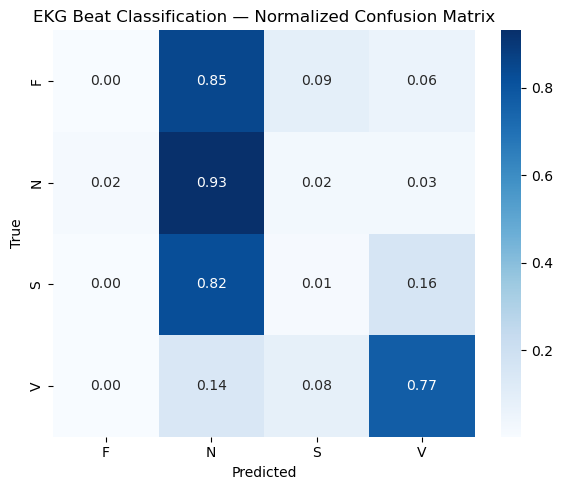

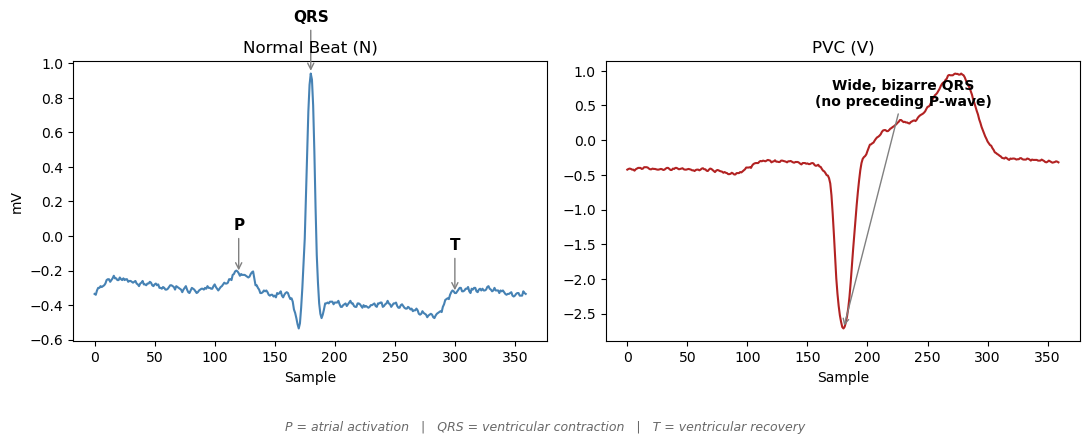

In [14]:
## Visualization

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EKG Beat Classification — Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=150)
plt.show()

# Annotated N vs. PVC comparison figure
n_idx = np.where(y_test == 'N')[0][0]
v_idx = np.where(y_test == 'V')[0][0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(X_test[n_idx], color='steelblue')
axes[0].set_title('Normal Beat (N)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('mV')

axes[0].annotate('P', xy=(120, X_test[n_idx][120]), xytext=(120, X_test[n_idx][120] + 0.25),
                  ha='center', fontsize=11, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate('QRS', xy=(180, X_test[n_idx][180]), xytext=(180, X_test[n_idx][180] + 0.3),
                  ha='center', fontsize=11, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate('T', xy=(300, X_test[n_idx][300]), xytext=(300, X_test[n_idx][300] + 0.25),
                  ha='center', fontsize=11, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='gray'))

axes[1].plot(X_test[v_idx], color='firebrick')
axes[1].set_title('PVC (V)')
axes[1].set_xlabel('Sample')

axes[1].annotate('Wide, bizarre QRS\n(no preceding P-wave)',
                  xy=(180, X_test[v_idx][180]), xytext=(230, 0.5),
                  ha='center', fontsize=10, fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.01,
          'P = atrial activation   |   QRS = ventricular contraction   |   T = ventricular recovery',
          ha='center', fontsize=9, style='italic', color='dimgray')

plt.savefig('normal_vs_pvc_annotated.png', dpi=150)
plt.show()